In [ ]:
import pandas as pd
import numpy as np

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

import matplotlib.pyplot as plt
import plotly.express as px

from datetime import date




# 1.

In [3]:
df = pd.read_csv('SP500.csv', parse_dates=['observation_date'])
df = df.sort_values('observation_date')
df = df.dropna()

train = df.iloc[1900:2200].copy()  
test  = df.iloc[2200:2220].copy()   

Zbiór danych podzielono na próbę treningową (n = 300) oraz próbę testową (H = 20), wykorzystywaną wyłącznie do oceny prognoz ex post.

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 1969 to 2279
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  300 non-null    datetime64[ns]
 1   SP500             300 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.0 KB


In [5]:
train.describe()

,observation_date,SP500
count,300,300.000000
mean,2024-03-16 02:19:12,5022.525467
min,2023-08-11 00:00:00,4117.370000
25%,2023-11-27 18:00:00,4553.812500
50%,2024-03-16 12:00:00,5087.915000
75%,2024-07-03 12:00:00,5439.000000
max,2024-10-18 00:00:00,5864.670000
std,NaN,474.746638


W badanym okresie wartości indeksu S&P 500 mieściły się w przedziale [4117; 5865], ze średnim poziomem około 5023 punktów.

In [6]:
px.line(train, x='observation_date', y='SP500', 
        title='S&P 500 - wybrany szereg czasowy (n = 300)', 
        labels={'SP500': 'Wartość Indeksu', 'observation_date': 'Data'}).show()

Wykres poziomu szeregu wskazuje na obecność trendu wzrostowego, co sugeruje niestacjonarność szeregu $X_{t}$

In [7]:
train['log_return'] = np.log(train['SP500']).diff()

In [8]:
px.line(
    train,
    x='observation_date',
    y='log_return',
    title='Log-zwroty S&P 500 (próbka treningowa)',
    labels={'log_return': 'Log-zwroty', 'observation_date': 'Data'}
)

In [9]:
px.histogram(
    train,
    x='log_return',
    nbins=40,
    title='Rozkład log-zwrotów',
    labels={'log_return': 'Log-zwroty', 'count': 'Częstość'}
)

Log-zwroty indeksu nie wykazują trendu i oscylują wokół zera, co sugeruje ich potencjalną stacjonarność. Rozkład charakteryzuje się zwiększoną koncentracją obserwacji wokół średniej oraz obecnością obserwacji skrajnych.

# 2.

## 2.1. Wykres ACF i PACF

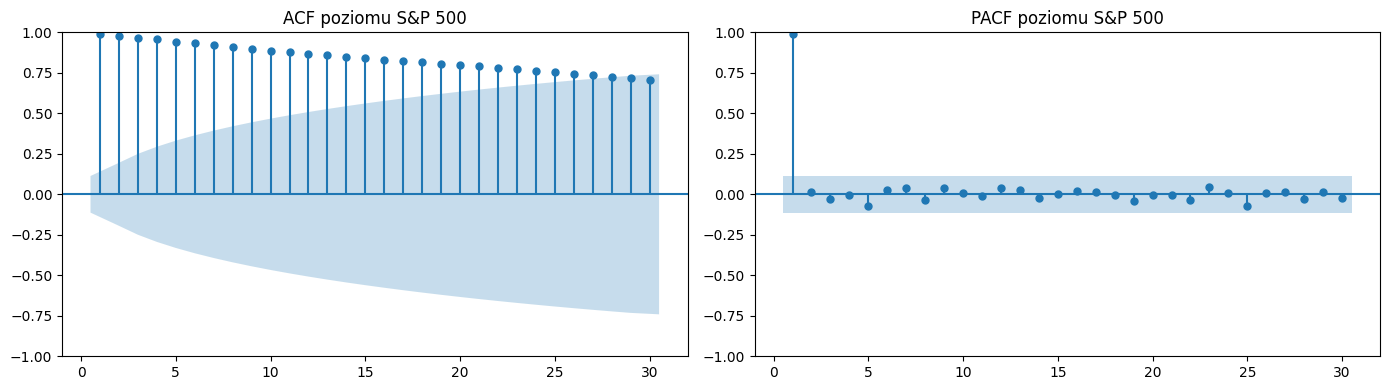

In [10]:
y = train['SP500']

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y, lags=30, ax=ax[0], zero=False)
ax[0].set_title('ACF poziomu S&P 500')

plot_pacf(y, lags=30, ax=ax[1], method='ywm', zero=False)
ax[1].set_title('PACF poziomu S&P 500')

plt.tight_layout()
plt.show()

Wykresy ACF i PACF log-zwrotów nie wskazują na istnienie silnej struktury zależności liniowej. Autokorelacje są niewielkie i w większości nieistotne statystycznie, co jest typowe dla dziennych danych finansowych.

## 2.2. Test stacjonarności ADF dla poziomu

Hipotezy:

- $H_0$: szereg niestacjonarny

- $H_1$: szereg stacjonarny

In [11]:
adf_level = adfuller(y)

print(f"ADF stat: {adf_level[0]:.4f}")
print(f"p-value: {adf_level[1]:.4f}")

ADF stat: -0.1017
p-value: 0.9493


Test ADF nie potwierdza stacjonarności poziomu szeregu, co uzasadnia zastosowanie różnicowania.

## 2.3. Różnicowanie (d = 1)

In [12]:
y_diff = y.diff().dropna()

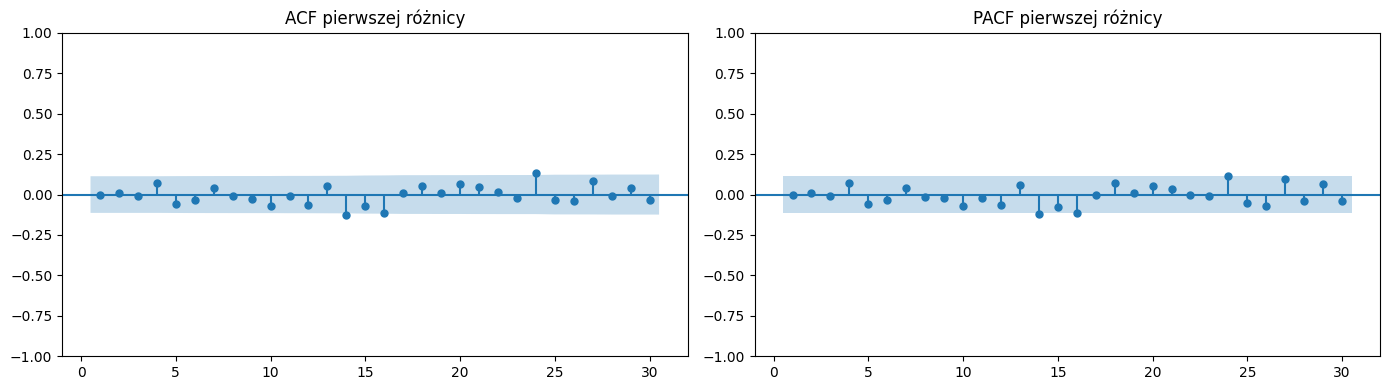

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_diff, lags=30, ax=ax[0], zero=False)
ax[0].set_title('ACF pierwszej różnicy')

plot_pacf(y_diff, lags=30, ax=ax[1], method='ywm', zero=False)
ax[1].set_title('PACF pierwszej różnicy')

plt.tight_layout()
plt.show()

In [14]:
adf_diff = adfuller(y_diff)

print(f"ADF stat (diff): {adf_diff[0]:.4f}")
print(f"p-value (diff): {adf_diff[1]:.4f}")

ADF stat (diff): -17.2297
p-value (diff): 0.0000


Na podstawie analizy ACF/PACF oraz testu ADF stwierdzono, że poziom szeregu jest niestacjonarny, natomiast jego pierwsza różnica spełnia warunki stacjonarności. W dalszej części rozważono modele klasy ARIMA(p,1,q), gdzie rzędy p i q dobrano na podstawie wykresów ACF/PACF oraz kryteriów informacyjnych.

Na podstawie analizy wykresów ACF i PACF oraz testu ADF stwierdzono, że poziom szeregu indeksu S&P 500 jest niestacjonarny, natomiast jego pierwsza różnica spełnia warunki stacjonarności. W związku z tym w dalszej części pracy do modelowania zastosowano modele klasy ARIMA z rzędem różnicowania d = 1.

# 3.

## 3.1 Dopasowanie modeli i porównanie AIC/BIC

In [26]:
# train_ts = train.set_index('observation_date')['SP500']
# test_ts  = test.set_index('observation_date')['SP500']
train_ts = (train
            .set_index('observation_date')['SP500']
            .sort_index()
            .asfreq('B'))  # dni robocze

test_ts = (test
           .set_index('observation_date')['SP500']
           .sort_index()
           .asfreq('B'))

In [69]:
candidates = [(p,1,q) for p in range(0,4) for q in range(0,4)]

rows = []
fits = {}

for order in candidates:
    model = ARIMA(train_ts, order=order, trend='n')
    res = model.fit()
    fits[order] = res
    rows.append({
        "model": f"ARIMA{order}",
        "order": order,
        "AIC": res.aic,
        "BIC": res.bic,
        "LLF": res.llf
    })


cmp = pd.DataFrame(rows).sort_values(["BIC", "AIC"]).reset_index(drop=True)
cmp

c:\REPO\studia\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\REPO\studia\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

c:\REPO\studia\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



,model,order,AIC,BIC,LLF
0,"ARIMA(0, 1, 0)","(0, 1, 0)",3053.531611,3057.268183,-1525.765805
1,"ARIMA(1, 1, 0)","(1, 1, 0)",3055.522011,3062.995156,-1525.761006
2,"ARIMA(0, 1, 1)","(0, 1, 1)",3055.522460,3062.995604,-1525.761230
3,"ARIMA(1, 1, 1)","(1, 1, 1)",3057.289115,3068.498831,-1525.644557
4,"ARIMA(2, 1, 0)","(2, 1, 0)",3057.345922,3068.555639,-1525.672961
5,"ARIMA(0, 1, 2)","(0, 1, 2)",3057.375365,3068.585082,-1525.687683
6,"ARIMA(1, 1, 2)","(1, 1, 2)",3058.316618,3073.262907,-1525.158309
7,"ARIMA(2, 1, 1)","(2, 1, 1)",3058.421989,3073.368278,-1525.210994
8,"ARIMA(3, 1, 0)","(3, 1, 0)",3059.323534,3074.269823,-1525.661767
9,"ARIMA(0, 1, 3)","(0, 1, 3)",3059.360054,3074.306343,-1525.680027


In [70]:
best_order = tuple(cmp.loc[0, "order"])
best_res = fits[best_order]
best_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  SP500   No. Observations:                  311
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1525.766
Date:                Sun, 25 Jan 2026   AIC                           3053.532
Time:                        00:54:11   BIC                           3057.268
Sample:                    08-11-2023   HQIC                          3055.025
                         - 10-18-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1544.4276    104.903     14.722      0.000    1338.820    1750.035
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                30.26
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               1.93   Skew:                            -0.42
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Porównano modele ARIMA(p, 1, q), dla $p,q\in\{0, 1, 2, 3\}$. Najniższe wartości kryteriów AIC i BIC uzyskał model ARIMA(0,1,0), dlatego został wybrany jako model końcowy. Odpowiada on procesowi błądzenia losowego bez dryfu: $X_t = X_{t-1} + \epsilon_t$

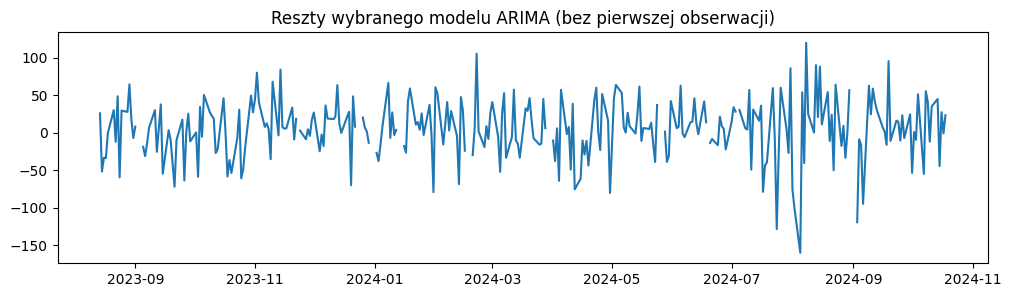

In [80]:
resid = best_res.resid

resid_plot = resid.iloc[1:]
plt.figure(figsize=(12,3))
plt.plot(resid_plot)
plt.title("Reszty wybranego modelu ARIMA (bez pierwszej obserwacji)")
plt.show()

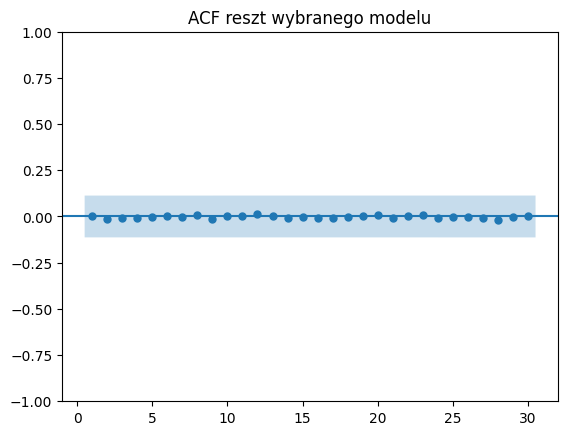

In [83]:
resid = best_res.resid.dropna()
plot_acf(resid, lags=30, zero=False)
plt.title("ACF reszt wybranego modelu")
plt.show()

In [82]:
lb = acorr_ljungbox(resid.dropna(), lags=10, return_df=True)
lb

,lb_stat,lb_pvalue
1,0.006371,0.936379
2,0.052182,0.974246
3,0.075183,0.994639
4,0.089857,0.999020
5,0.091874,0.999868
6,0.098559,0.999981
7,0.101218,0.999998
8,0.127845,0.999999
9,0.196763,0.999999
10,0.200838,1.000000


Wykres ACF reszt nie wskazuje na istotną autokorelację, a test Ljunga–Boxa dla opóźnień do 10 nie wykazał podstaw do odrzucenia hipotezy o braku autokorelacji reszt (p-value > 0.05), co potwierdza poprawną specyfikację modelu. Uzyskane wysokie wartości p-value testu Ljunga–Boxa świadczą o bardzo słabej zależności liniowej w resztach, zgodnej z założeniem białego szumu.

# 4.

In [75]:
H = 20
model = ARIMA(train_ts, order=(0,1,0), trend='n')
res = model.fit()

fc = res.get_forecast(steps=H)
fc_mean = fc.predicted_mean
fc_ci = fc.conf_int(alpha=0.05)

fc_mean.index = test_ts.index
fc_ci.index = test_ts.index

In [76]:
y_true = test_ts
y_pred = fc_mean
ci = fc_ci

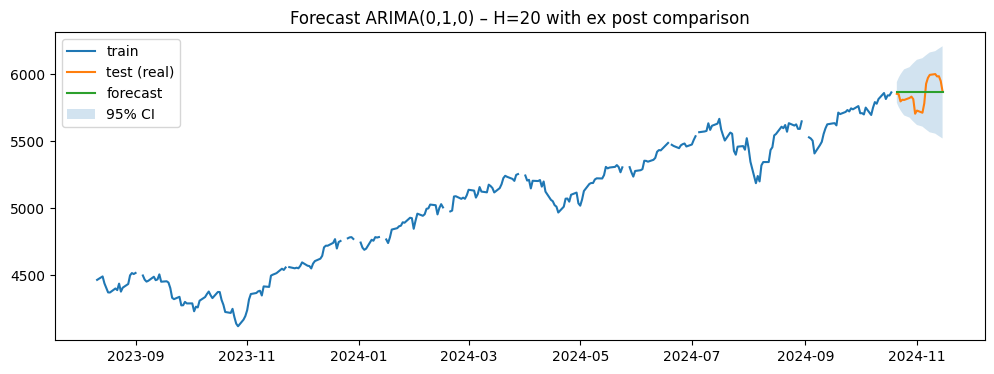

In [77]:
plt.figure(figsize=(12,4))
plt.plot(train_ts.index, train_ts, label="train")
plt.plot(y_true.index, y_true, label="test (real)")
plt.plot(y_pred.index, y_pred, label="forecast")
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.2, label="95% CI")
plt.title("Forecast ARIMA(0,1,0) – H=20 with ex post comparison")
plt.legend()
plt.show()

In [78]:
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE:  81.324
RMSE: 94.243


Na podstawie wybranego w punkcie 3 modelu ARIMA(0,1,0) wyznaczono prognozy punktowe oraz 95% przedziały predykcji dla horyzontu $H=20$ sesji. Prognozę skonfrontowano z rzeczywistymi obserwacjami z próby testowej (kolejne 20 notowań po próbie treningowej). Prognoza punktowa ma charakter błądzenia losowego bez dryfu, tj. w przybliżeniu utrzymuje ostatni poziom z próby treningowej, natomiast szerokość przedziałów predykcji rośnie wraz z horyzontem. Jakość prognoz oceniono przy użyciu miar MAE i RMSE, uzyskując odpowiednio MAE = 81.3 oraz RMSE = 94.2 punktu indeksowego.

W projekcie przeprowadzono analizę szeregu czasowego indeksu S&P 500 na wybranym odcinku $n=300$. Analiza ACF/PACF oraz test ADF wykazały niestacjonarność poziomu szeregu, natomiast pierwsza różnica okazała się stacjonarna, co uzasadniło zastosowanie modeli ARIMA z $d=1$. Spośród rozważanych modeli ARIMA(p, 1, q), dla $p,q\in\{0, 1, 2, 3\}$ najlepsze wartości AIC/BIC uzyskał model ARIMA(0,1,0). Diagnostyka reszt (ACF oraz test Ljunga–Boxa) nie wykazała istotnej autokorelacji, co potwierdza adekwatność modelu. Dla horyzontu $H=20$ wykonano prognozy punktowe i przedziałowe oraz oceniono je ex post, uzyskując MAE = 81.3 i RMSE = 94.2.